In [1]:
import os
import numpy as np

os.chdir("../..")
savedir = "data/Chemistry"

In [2]:
import scipy.sparse as sp
from tensorly.tucker_tensor import TuckerTensor
from tensorly.tucker_tensor import tucker_to_tensor
from src.Utils.utils import *
from src.Bases.rbf import RBFWeights
from src.Bases.lidw import lidw
import matplotlib.pyplot as plt

In [3]:
snaps = np.load(savedir+'/chemical_traj_uva_2024_600.npy').transpose((1,2,0))
#snaps[snaps==0] = 1e-16
snaps.shape

(578, 1001, 600)

In [4]:
snaps_test = np.load(savedir+'/chemical_traj_uva_2024_32_test.npy').transpose((1,2,0))
#snaps_test[snaps_test==0] = 1e-16
snaps.shape

(578, 1001, 600)

In [5]:
snaps_flat = snaps.reshape(-1, np.prod(snaps.shape[1:]))
snaps_flat.shape

(578, 600600)

In [47]:
mu = np.mean(snaps_flat, axis=1, keepdims=1)
std = np.std(snaps_flat, axis=1, keepdims=1)
std[std == 0 ] = 1
snaps0 = (snaps.transpose((1,0,2)) - mu) / std
snaps0 = snaps0.transpose((1,0,2))
snaps0.shape, mu.shape

((578, 1001, 600), (578, 1))

In [48]:
snaps_test0 = (snaps_test.transpose((1,0,2)) - mu) / std
snaps_test0 = snaps_test0.transpose((1,0,2))
snaps_test0.shape, mu.shape

((578, 1001, 32), (578, 1))

In [49]:
params_train = np.load(savedir+"/params_train.npy")
params_test  = np.load(savedir+"/params_test.npy")
params_train.shape, params_test.shape

((600, 5), (32, 5))

In [50]:
# Time horizon
nsec = 3600 * 24 * 365
tf_eval = 1e7 * nsec 
Nt = 1000                         
t_eval = np.unique(np.concatenate([
    [0.0],
    np.logspace(-6, np.log10(tf_eval / nsec), Nt) * nsec
]))
t_eval_test = t_eval[:-1]/2 + t_eval[1:]/2

In [51]:
core, factors = load_tucker_npz(os.path.join(savedir, "tucker_100x200x200.npz"))
tucker_tensor = TuckerTensor((core, factors))
print("E: ", tucker_tensor.shape)


E:  (578, 1001, 600)


In [52]:
X_hat = tucker_to_tensor((core, factors))
tl.norm(snaps0 - X_hat) / tl.norm(snaps0)

np.float64(0.15937642565241417)

In [53]:
r_arr = [1, 5, 10, 20, 40, 80, 120]
r_arr = np.asarray(r_arr, dtype=int)

## Single run

In [54]:
mut = np.mean(params_train, axis=0)
stdt = np.std(params_train, axis=0)
params_train0 = (params_train-mut)/stdt
params_test0 = (params_test-mut)/stdt

In [55]:
rbfw = RBFWeights(
        mus=params_train0,
        basis="gaussian", 
        eps=1,
        order=-1,       
        nugget=0)
idx = 2
W_rbf     = rbfw.weights(params_test0[idx])
U_rbf, s_rbf, _ = buildParBasis(tucker_tensor, W_rbf)
np.linalg.norm(U_rbf @ (U_rbf.T @ snaps_test0[...,idx]) - snaps_test0[...,idx])/np.linalg.norm(snaps_test0[...,idx])


np.float64(0.0721074302581655)

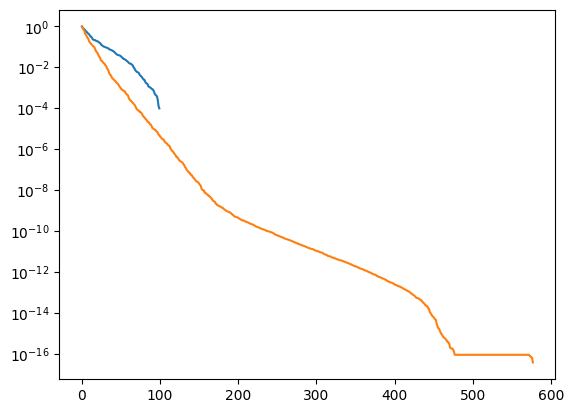

In [56]:
U0, S0, VT0 = np.linalg.svd(snaps0[...,idx])
plt.semilogy(s_rbf/s_rbf[0])
plt.semilogy(S0/S0[0])